In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

In [9]:
df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [15]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [12]:
df['ph'] = df['ph'].fillna(df['ph'].median())

In [13]:
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())

In [14]:
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

In [19]:
df.shape

(3276, 10)

In [20]:
correlation_matrix = df.corr()['Potability']

In [21]:
correlation_matrix

ph                -0.003014
Hardness          -0.013837
Solids             0.033743
Chloramines        0.023779
Sulfate           -0.020476
Conductivity      -0.008128
Organic_carbon    -0.030001
Trihalomethanes    0.006887
Turbidity          0.001581
Potability         1.000000
Name: Potability, dtype: float64

In [24]:
corr_matrix = df.corr()

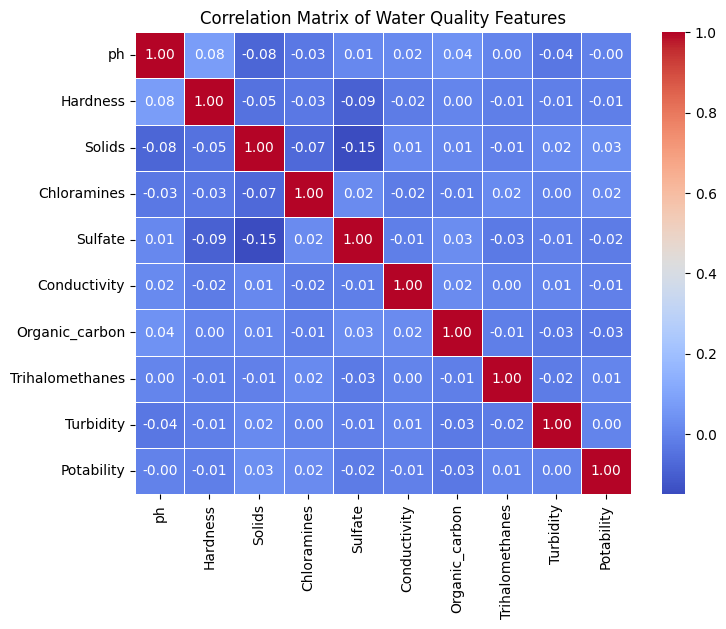

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Water Quality Features')
plt.show()

In [26]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1 ]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
classifier = RandomForestClassifier(random_state=42, class_weight='balanced')
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 15]
}
grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("The Best Settings:", grid_search.best_params_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
The Best Settings: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [39]:
rm_model = grid_search.best_estimator_

In [40]:
y_pred = rm_model.predict(X_test)

In [46]:
print("Accuracy Score:", accuracy_score(y_test, y_pred)*100)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 67.83536585365853

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.88      0.77       412
           1       0.62      0.34      0.44       244

    accuracy                           0.68       656
   macro avg       0.66      0.61      0.61       656
weighted avg       0.67      0.68      0.65       656



In [48]:
import pickle
with open('water_model.pkl', 'wb') as file:
    pickle.dump(rm_model, file)
print('Finished')

Finished
